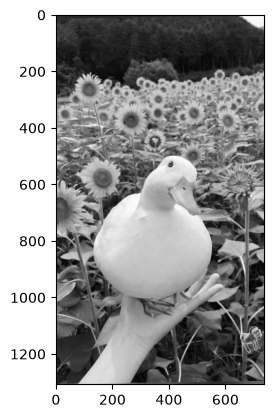

In [2]:
import numpy as np
import cv2
import copy
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error


image = cv2.imread('goose.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image_gray, cmap="gray")


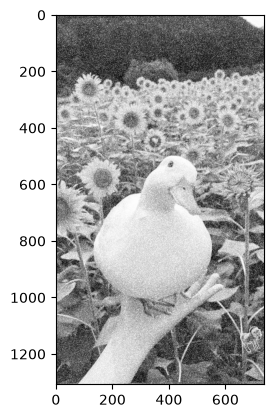

In [3]:
# Генерация гауссова шума 
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

image_noise_gauss = cv2.add(image_gray,noise_gauss)
plt.imshow(image_noise_gauss, cmap="gray")

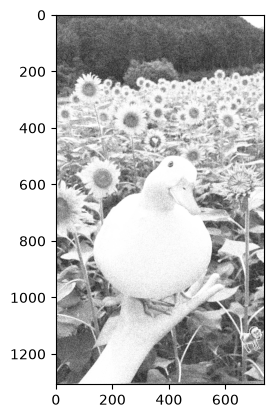

In [4]:
# Генерация постоянного шума (соль и перец)
np.random.seed(100)
a, b = 25, 125
noise_constant = np.random.uniform(a, b, image_gray.shape).astype(np.uint8)

image_noise_constant = cv2.add(image_gray, noise_constant)
plt.imshow(image_noise_constant, cmap='gray')

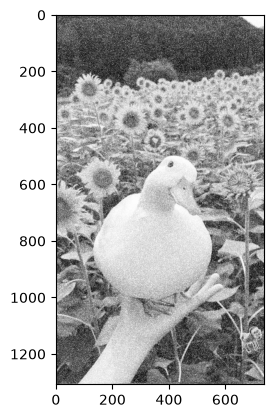

In [52]:
# Наложение гауссова шума на изображение 
image_noise_gauss = cv2.add(image_gray, noise_gauss)

plt.imshow(image_noise_gauss, cmap="gray");


In [ ]:
# Метрики зашумлённого гауссовым шумом изображения
mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim, diff) = structural_similarity(image_gray, image_noise_gauss, full=True)
print(mse_gauss, ssim)

3212.3581077150643 0.16541802615773774


803.489378697979 0.38623193161271496


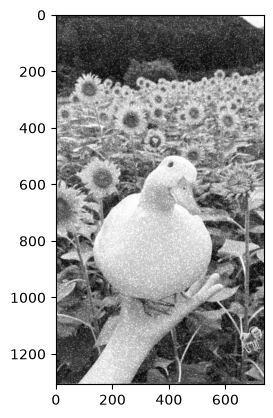

In [ ]:
# Медианный фильтр для гауссова шума
image_gauss_median = cv2.medianBlur(image_noise_gauss, 3)

mse_gauss_median = mean_squared_error(image_gray, image_gauss_median)
(ssim_gauss_median, diff) = structural_similarity(image_gray, image_gauss_median, full=True)
print(mse_gauss_median, ssim_gauss_median)

plt.imshow(image_gauss_median, cmap="gray");

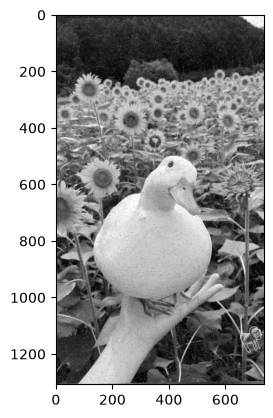

In [ ]:
# Наложение постоянного шума на изображение
image_sp = copy.deepcopy(image_gray)
image_sp[zeros_pixel] = 0
image_sp[ones_pixel] = 255

plt.imshow(image_sp, cmap="gray");

In [ ]:
# Метрики зашумлённого постоянным шумом изображения
mse_sp = mean_squared_error(image_gray, image_sp)
(ssim_sp, diff) = structural_similarity(image_gray, image_sp, full=True)
print(mse_sp, ssim_sp)

413.369714798564 0.6343650043228198


4.670121576253158 0.9899929801166567


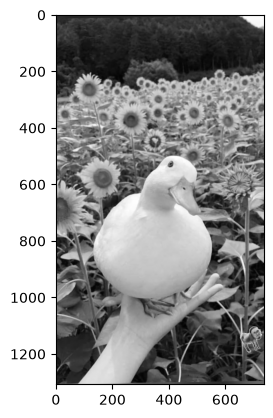

In [ ]:
# Медианный фильтр для постоянного шума
image_sp_median = cv2.medianBlur(image_sp, 3)

mse_sp_median = mean_squared_error(image_gray, image_sp_median)
(ssim_sp_median, diff) = structural_similarity(image_gray, image_sp_median, full=True)
print(mse_sp_median, ssim_sp_median)

plt.imshow(image_sp_median, cmap="gray");

In [ ]:
# Другие типы фильтров для гауссова шума
image_gauss_gauss = cv2.GaussianBlur(image_noise_gauss, (5, 5), 0)
image_gauss_bilat = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
image_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h=20)

Median k=3 803.489378697979 0.38623193161271496
Median k=5 439.2052845781811 0.5788251918092698
Gaussian 3x3 1430.4828064752028 0.45087481202016133
Gaussian 5x5 1302.0357166600186 0.5611834520580963
Bilateral d=5 2049.4642490609626 0.30760850320787825
Bilateral d=9 1344.5318296270443 0.4557203558450988
NLM h=10 3204.5933563106637 0.1854613022041489
NLM h=20 3029.8350171602847 0.28818451773973025


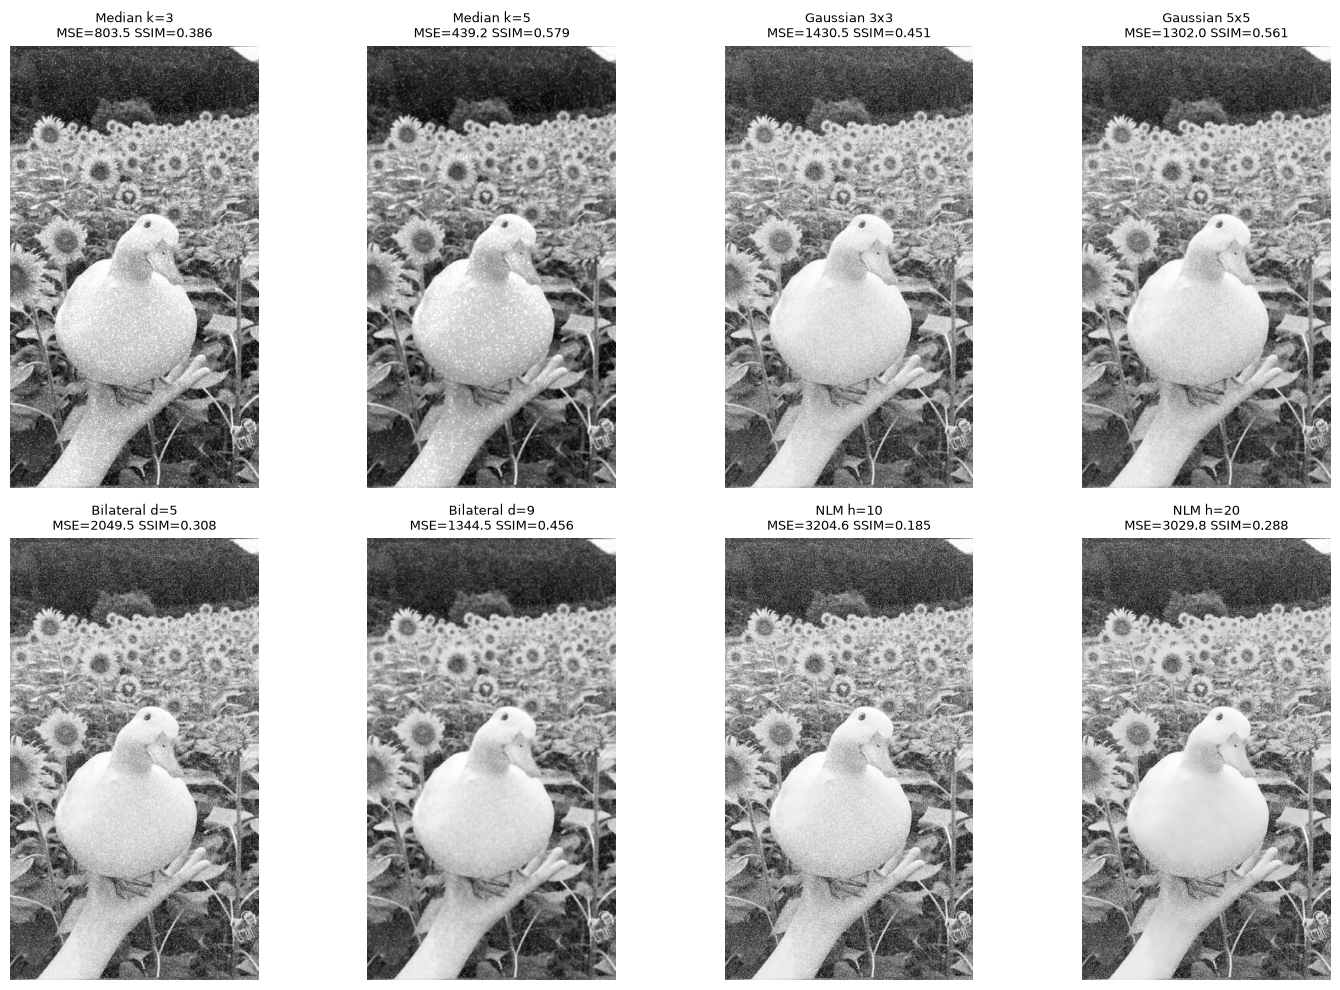

Лучший фильтр для гауссова шума: Median k=5


In [62]:
# Фильтрация гауссова шума
filters_gauss = {
    "Median k=3":    cv2.medianBlur(image_noise_gauss, 3),
    "Median k=5":    cv2.medianBlur(image_noise_gauss, 5),
    "Gaussian 3x3":  cv2.GaussianBlur(image_noise_gauss, (3, 3), 0),
    "Gaussian 5x5":  cv2.GaussianBlur(image_noise_gauss, (5, 5), 0),
    "Bilateral d=5": cv2.bilateralFilter(image_noise_gauss, 5, 50, 50),
    "Bilateral d=9": cv2.bilateralFilter(image_noise_gauss, 9, 75, 75),
    "NLM h=10":      cv2.fastNlMeansDenoising(image_noise_gauss, h=10),
    "NLM h=20":      cv2.fastNlMeansDenoising(image_noise_gauss, h=20),
}

res_gauss = {}
plt.figure(figsize=(15, 10))
for i, (name, img) in enumerate(filters_gauss.items()):
    mse = mean_squared_error(image_gray, img)
    ssim = structural_similarity(image_gray, img)
    res_gauss[name] = (mse, ssim)
    print(name, mse, ssim)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title("{}\nMSE={:.1f} SSIM={:.3f}".format(name, mse, ssim), fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

best_gauss = min(res_gauss, key=lambda k: res_gauss[k][0])
print("Лучший фильтр для гауссова шума:", best_gauss)

Median k=3 4.670121576253158 0.9899929801166567
Median k=5 18.89098752659221 0.9645364728918013
Gaussian 3x3 65.31154849754022 0.8032466946946326
Gaussian 5x5 46.065199732415905 0.8535816606491924
Bilateral d=5 353.0501367005717 0.6907437636855667
Bilateral d=9 152.39245009805876 0.7523907371136022
NLM h=10 394.7397651160085 0.6563549754875988
NLM h=20 103.56639949807206 0.8036651021128115


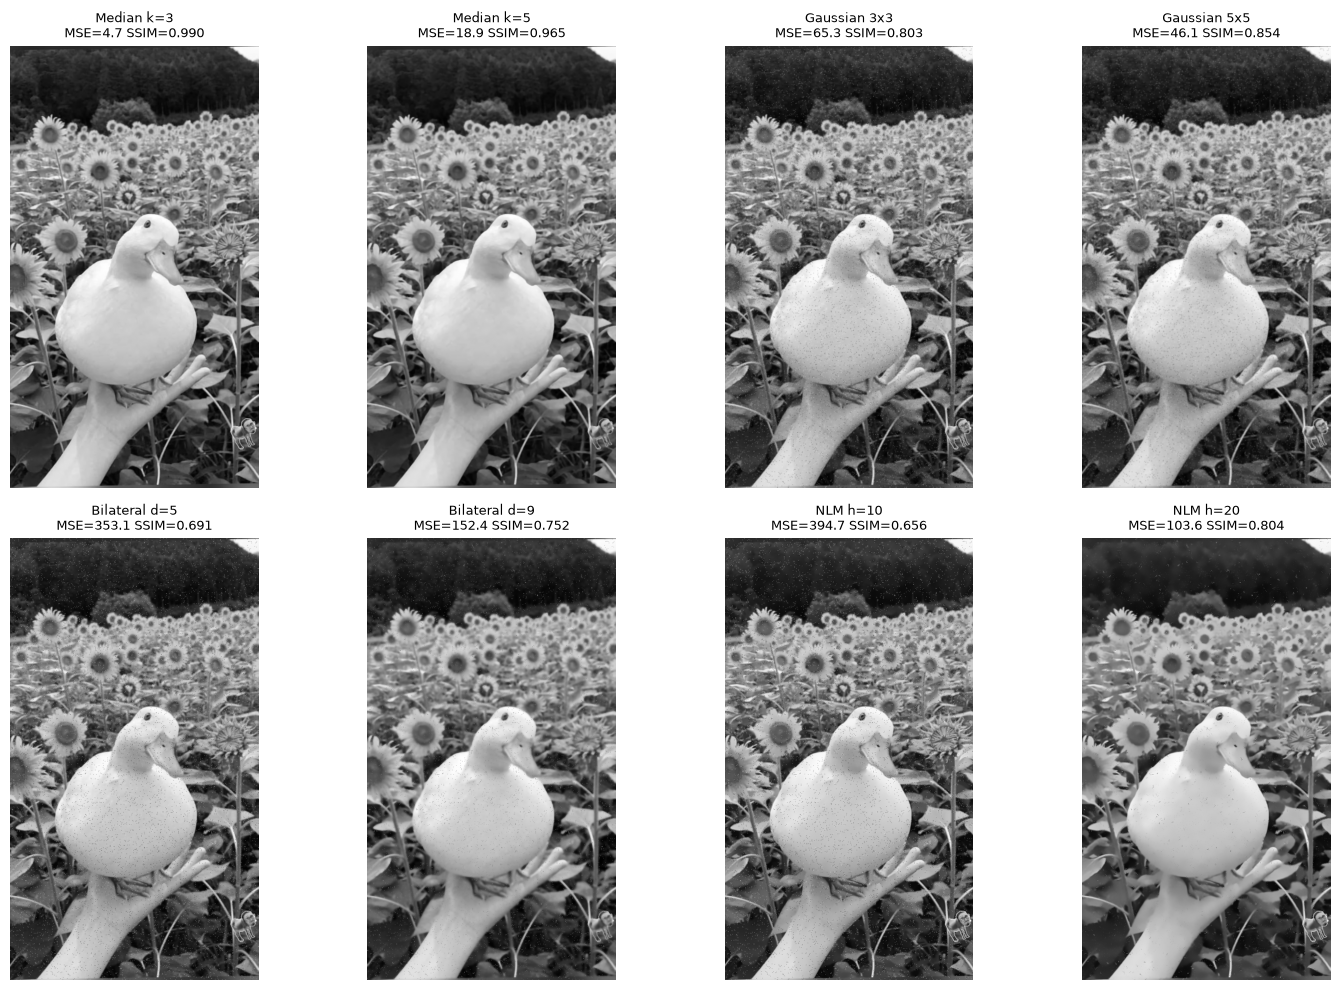

Лучший фильтр для постоянного шума: Median k=3


In [63]:
# Фильтрация постоянного шума (соль и перец)
filters_sp = {
    "Median k=3":    cv2.medianBlur(image_sp, 3),
    "Median k=5":    cv2.medianBlur(image_sp, 5),
    "Gaussian 3x3":  cv2.GaussianBlur(image_sp, (3, 3), 0),
    "Gaussian 5x5":  cv2.GaussianBlur(image_sp, (5, 5), 0),
    "Bilateral d=5": cv2.bilateralFilter(image_sp, 5, 50, 50),
    "Bilateral d=9": cv2.bilateralFilter(image_sp, 9, 75, 75),
    "NLM h=10":      cv2.fastNlMeansDenoising(image_sp, h=10),
    "NLM h=20":      cv2.fastNlMeansDenoising(image_sp, h=20),
}

res_sp = {}
plt.figure(figsize=(15, 10))
for i, (name, img) in enumerate(filters_sp.items()):
    mse = mean_squared_error(image_gray, img)
    ssim = structural_similarity(image_gray, img)
    res_sp[name] = (mse, ssim)
    print(name, mse, ssim)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title("{}\nMSE={:.1f} SSIM={:.3f}".format(name, mse, ssim), fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

best_sp = min(res_sp, key=lambda k: res_sp[k][0])
print("Лучший фильтр для постоянного шума:", best_sp)